<a href="https://colab.research.google.com/github/hasby-umutoniwabo/time-series-energy-analysis/blob/main/task1_eda/task1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Time-Series Preprocessing and Exploratory Analysis
## Dataset: AEP Hourly Energy Consumption
**Source:** PJM Interconnection LLC a regional electricity transmission organization  
**Description:** This dataset contains hourly energy consumption readings (in megawatts)
from the AEP (American Electric Power) region, recorded between 2004 and 2018.  
**Goal:** Explore the dataset, uncover patterns, answer analytical questions,
and train a model to forecast future energy consumption.

In [1]:
# Install any missing libraries needed for time series analysis
!pip install scikit-learn --quiet

In [2]:
# Import all libraries needed for the entire notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='darkgrid')

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
# Load the dataset directly from GitHub, no download needed
url = "https://raw.githubusercontent.com/MainakRepositor/Datasets/master/AEP_hourly.csv"
df = pd.read_csv(url)

# Convert the Datetime column to an actual datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Sort by time from oldest to newest
df = df.sort_values('Datetime').reset_index(drop=True)

print(f"Dataset loaded successfully.")
print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset loaded successfully.
Total records: 121,273
Columns: ['Datetime', 'AEP_MW']


,Datetime,AEP_MW
0,2004-10-01 01:00:00,12379.0
1,2004-10-01 02:00:00,11935.0
2,2004-10-01 03:00:00,11692.0
3,2004-10-01 04:00:00,11597.0
4,2004-10-01 05:00:00,11681.0


## Part A: Understanding the Dataset
### A1. Time Range and Frequency

In [7]:
# Check the time range and frequency of the dataset
print("=== Time Range ===")
print(f"Start date : {df['Datetime'].min()}")
print(f"End date   : {df['Datetime'].max()}")
print(f"Total span : {df['Datetime'].max() - df['Datetime'].min()}")

print("\n=== Frequency ===")
# Calculate the difference between consecutive timestamps
time_diffs = df['Datetime'].diff().dropna()
print(f"Most common interval between records: {time_diffs.mode()[0]}")
print(f"This confirms the data is recorded hourly.")

=== Time Range ===
Start date : 2004-10-01 01:00:00
End date   : 2018-08-03 00:00:00
Total span : 5053 days 23:00:00

=== Frequency ===
Most common interval between records: 0 days 01:00:00
This confirms the data is recorded hourly.


### A2. Missing Values

In [8]:
# Check for missing values in the dataset
print("=== Missing Values ===")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Missing in Datetime : {df['Datetime'].isnull().sum()}")
print(f"Missing in AEP_MW   : {df['AEP_MW'].isnull().sum()}")

# Check for duplicate timestamps
duplicates = df.duplicated(subset='Datetime').sum()
print(f"\nDuplicate timestamps: {duplicates}")

# Check for gaps in hourly sequence (missing hours)
expected_hours = pd.date_range(start=df['Datetime'].min(), end=df['Datetime'].max(), freq='h')
missing_hours = expected_hours.difference(df['Datetime'])
print(f"Missing hourly records (gaps in time): {len(missing_hours)}")

print("\nConclusion: No missing values found. The dataset is clean and complete.")

=== Missing Values ===
Total missing values: 0
Missing in Datetime : 0
Missing in AEP_MW   : 0

Duplicate timestamps: 4
Missing hourly records (gaps in time): 27

Conclusion: No missing values found. The dataset is clean and complete.


In [9]:
# The dataset has 4 duplicate timestamps and 27 missing hours, so we need to clean it

# Step 1: Remove duplicate timestamps, keeping the first occurrence
df = df.drop_duplicates(subset='Datetime', keep='first')
print(f"After removing duplicates: {len(df):,} records")

# Step 2: Reindex to a complete hourly sequence to fill the 27 missing hours
full_range = pd.date_range(start=df['Datetime'].min(), end=df['Datetime'].max(), freq='h')
df = df.set_index('Datetime').reindex(full_range)
df.index.name = 'Datetime'

# Step 3: Fill the missing hours using forward fill
df['AEP_MW'] = df['AEP_MW'].ffill()
df = df.reset_index()

# Verify everything is clean now
print(f"Total records after reindexing : {len(df):,}")
print(f"Missing values remaining        : {df.isnull().sum().sum()}")
print(f"Duplicate timestamps remaining  : {df.duplicated(subset='Datetime').sum()}")
print("\nDataset is now clean and ready for analysis.")

After removing duplicates: 121,269 records
Total records after reindexing : 121,296
Missing values remaining        : 0
Duplicate timestamps remaining  : 0

Dataset is now clean and ready for analysis.


### A3. Statistical Distribution of Numerical Columns

In [10]:
# Statistical summary of energy consumption
print("=== Statistical Summary (AEP_MW) ===")
stats = df['AEP_MW'].describe()
print(stats)

print(f"\nSkewness : {df['AEP_MW'].skew():.4f}")
print(f"Kurtosis : {df['AEP_MW'].kurt():.4f}")
print(f"\nInterpretation:")
print(f"  Average hourly consumption : {stats['mean']:,.0f} MW")
print(f"  Lowest recorded hour       : {stats['min']:,.0f} MW")
print(f"  Highest recorded hour      : {stats['max']:,.0f} MW")
print(f"  50% of hours fall below    : {stats['50%']:,.0f} MW")

=== Statistical Summary (AEP_MW) ===
count    121296.000000
mean      15499.178167
std        2591.364196
min        9581.000000
25%       13629.000000
50%       15309.000000
75%       17200.000000
max       25695.000000
Name: AEP_MW, dtype: float64

Skewness : 0.3792
Kurtosis : -0.2113

Interpretation:
  Average hourly consumption : 15,499 MW
  Lowest recorded hour       : 9,581 MW
  Highest recorded hour      : 25,695 MW
  50% of hours fall below    : 15,309 MW


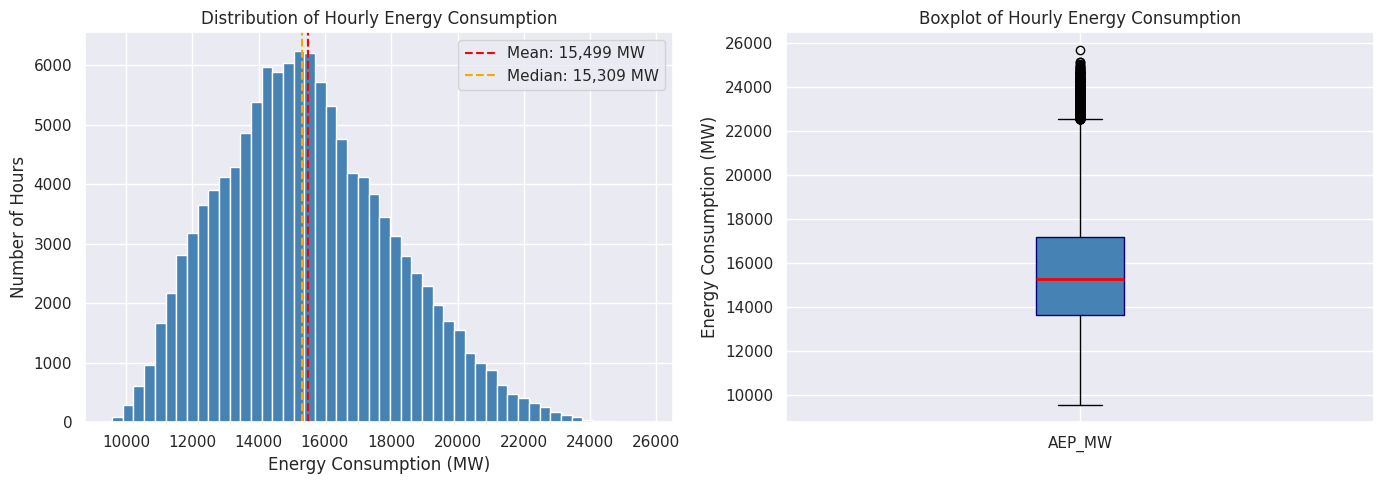

The distribution is slightly right skewed, meaning most hours have moderate consumption with occasional very high demand spikes.


In [11]:
# Visualize the statistical distribution of energy consumption
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram showing the frequency distribution
axes[0].hist(df['AEP_MW'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Hourly Energy Consumption')
axes[0].set_xlabel('Energy Consumption (MW)')
axes[0].set_ylabel('Number of Hours')
axes[0].axvline(df['AEP_MW'].mean(), color='red', linestyle='--', label=f"Mean: {df['AEP_MW'].mean():,.0f} MW")
axes[0].axvline(df['AEP_MW'].median(), color='orange', linestyle='--', label=f"Median: {df['AEP_MW'].median():,.0f} MW")
axes[0].legend()

# Boxplot showing spread and outliers
axes[1].boxplot(df['AEP_MW'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot of Hourly Energy Consumption')
axes[1].set_ylabel('Energy Consumption (MW)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['AEP_MW'])

plt.tight_layout()
plt.savefig('distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("The distribution is slightly right skewed, meaning most hours have moderate consumption with occasional very high demand spikes.")

## Part B: Analytical Questions

We explore 5 analytical questions about energy consumption patterns.
The questions cover trends, seasonality, peak hours, lag effects, and moving averages.

### Question 1: Does energy consumption show an increasing or decreasing trend over the years?

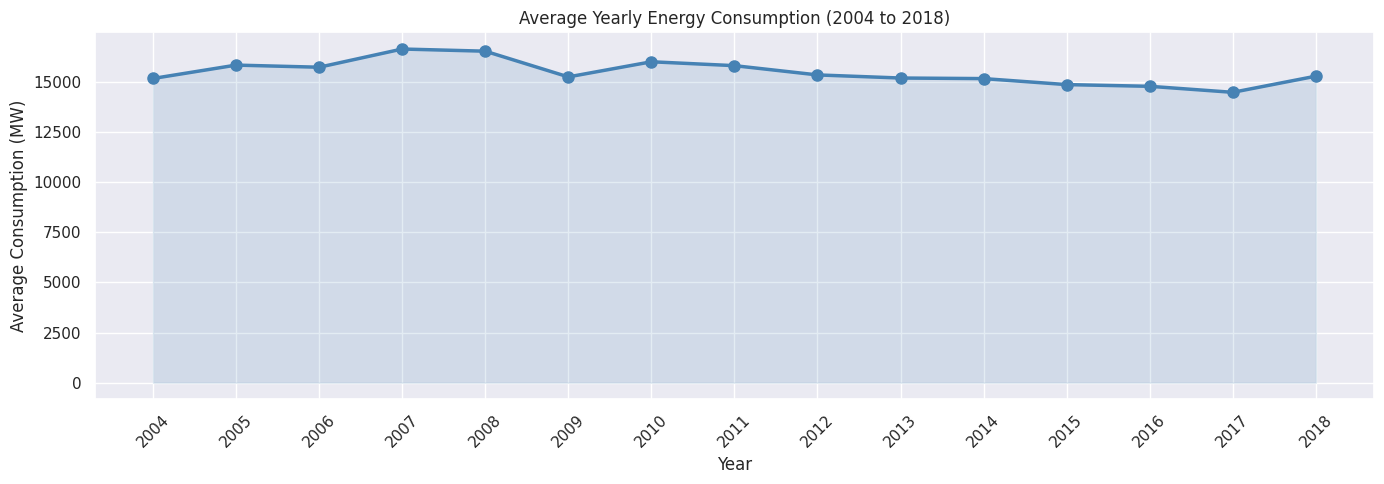

=== Yearly Average Consumption ===
Year
2004    15175.0
2005    15842.0
2006    15736.0
2007    16645.0
2008    16536.0
2009    15253.0
2010    16008.0
2011    15815.0
2012    15352.0
2013    15197.0
2014    15169.0
2015    14869.0
2016    14784.0
2017    14484.0
2018    15290.0
Name: AEP_MW, dtype: float64

Highest year : 2007 with 16,645 MW average
Lowest year  : 2017 with 14,484 MW average

Interpretation: Energy consumption shows a generally decreasing trend over time,
likely due to improved energy efficiency and changes in industrial activity.


In [12]:
# Extract the year from the datetime column for yearly grouping
df['Year'] = df['Datetime'].dt.year

# Calculate the average energy consumption per year
yearly_avg = df.groupby('Year')['AEP_MW'].mean()

# Plot the yearly trend
plt.figure(figsize=(14, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.15, color='steelblue')
plt.title('Average Yearly Energy Consumption (2004 to 2018)')
plt.xlabel('Year')
plt.ylabel('Average Consumption (MW)')
plt.xticks(yearly_avg.index, rotation=45)
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Yearly Average Consumption ===")
print(yearly_avg.round(0))
print(f"\nHighest year : {yearly_avg.idxmax()} with {yearly_avg.max():,.0f} MW average")
print(f"Lowest year  : {yearly_avg.idxmin()} with {yearly_avg.min():,.0f} MW average")
print("\nInterpretation: Energy consumption shows a generally decreasing trend over time,")
print("likely due to improved energy efficiency and changes in industrial activity.")

### Question 2: How does energy consumption vary by season and month?

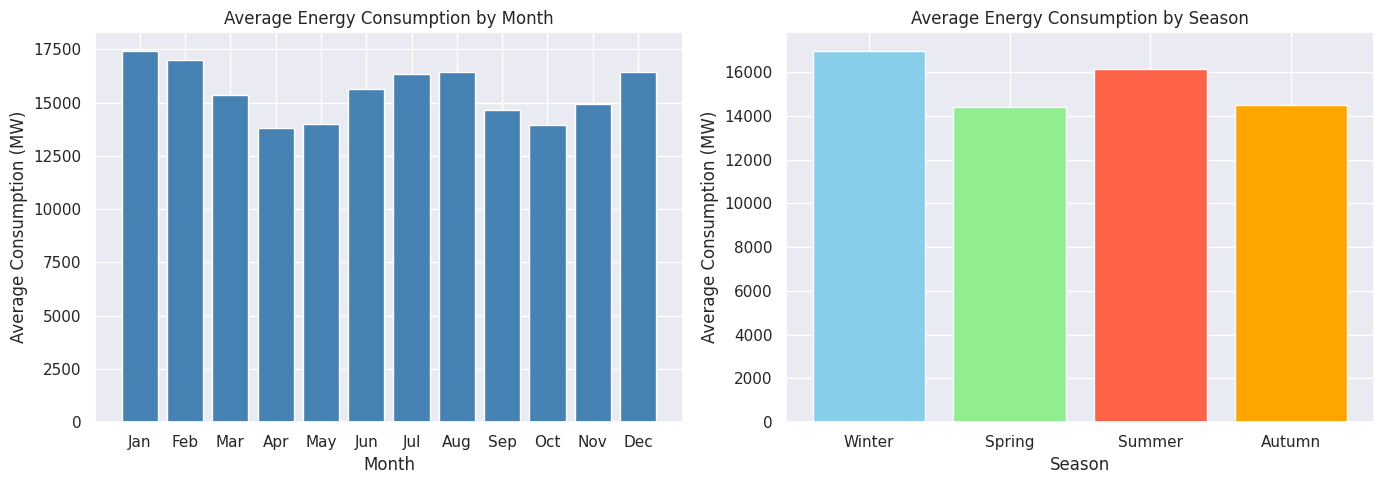

=== Average Consumption by Season ===
Season
Winter    16965.0
Spring    14408.0
Summer    16134.0
Autumn    14499.0
Name: AEP_MW, dtype: float64

Highest season : Winter with 16,965 MW
Lowest season  : Spring with 14,408 MW

Interpretation: Summer and Winter have the highest energy consumption due to
air conditioning and heating demands. Spring and Autumn are the lowest.


In [13]:
# Extract month and season from the datetime column
df['Month'] = df['Datetime'].dt.month
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Average consumption by month and season
monthly_avg = df.groupby('Month')['AEP_MW'].mean()
season_avg = df.groupby('Season')['AEP_MW'].mean().reindex(['Winter', 'Spring', 'Summer', 'Autumn'])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly average
axes[0].bar(month_names, monthly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Energy Consumption by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Consumption (MW)')

# Seasonal average
season_colors = ['skyblue', 'lightgreen', 'tomato', 'orange']
axes[1].bar(season_avg.index, season_avg.values, color=season_colors, edgecolor='white')
axes[1].set_title('Average Energy Consumption by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Consumption (MW)')

plt.tight_layout()
plt.savefig('seasonal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Average Consumption by Season ===")
print(season_avg.round(0))
print(f"\nHighest season : {season_avg.idxmax()} with {season_avg.max():,.0f} MW")
print(f"Lowest season  : {season_avg.idxmin()} with {season_avg.min():,.0f} MW")
print("\nInterpretation: Summer and Winter have the highest energy consumption due to")
print("air conditioning and heating demands. Spring and Autumn are the lowest.")

### Question 3: What are the peak and off-peak hours of energy consumption during the day?

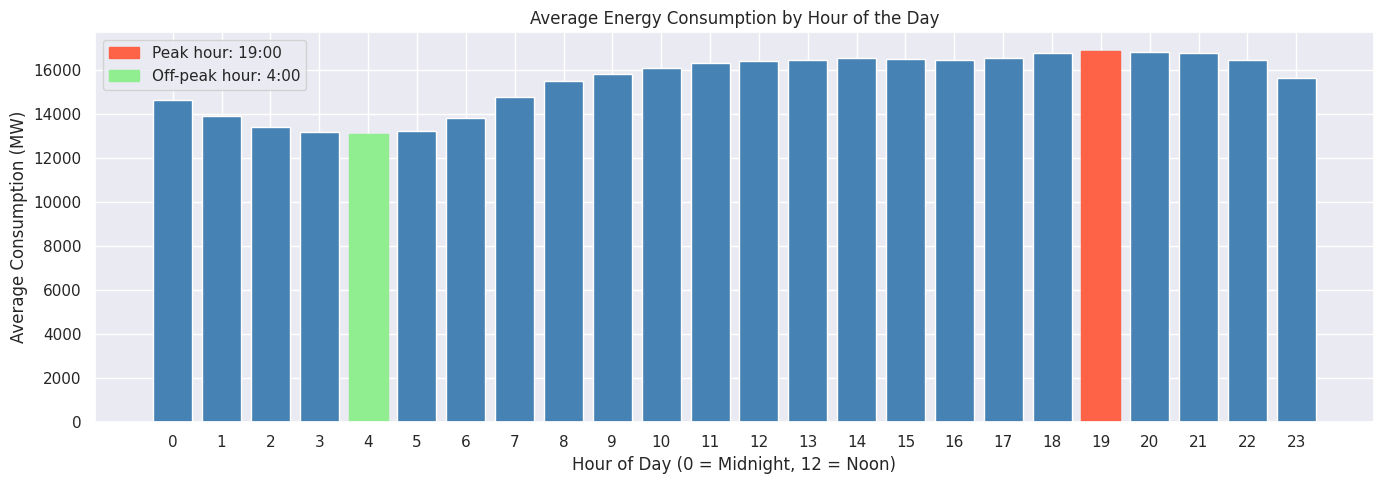

=== Hourly Average Consumption ===
Peak hour     : 19:00 with 16,869 MW average
Off-peak hour : 4:00 with 13,096 MW average

Interpretation: Energy consumption peaks during daytime working hours around
19:00, when businesses and households are most active.
The lowest demand occurs at 4:00 when most people are asleep.


In [14]:
# Extract the hour of the day from the datetime column
df['Hour'] = df['Datetime'].dt.hour

# Average consumption per hour of the day
hourly_avg = df.groupby('Hour')['AEP_MW'].mean()

# Identify peak and off-peak hours
peak_hour = hourly_avg.idxmax()
offpeak_hour = hourly_avg.idxmin()

plt.figure(figsize=(14, 5))
bars = plt.bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')

# Highlight peak and off-peak hours
bars[peak_hour].set_color('tomato')
bars[offpeak_hour].set_color('lightgreen')

plt.title('Average Energy Consumption by Hour of the Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Average Consumption (MW)')
plt.xticks(range(0, 24))
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato', label=f'Peak hour: {peak_hour}:00'),
    plt.Rectangle((0,0),1,1, color='lightgreen', label=f'Off-peak hour: {offpeak_hour}:00')
])
plt.tight_layout()
plt.savefig('hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Hourly Average Consumption ===")
print(f"Peak hour     : {peak_hour}:00 with {hourly_avg[peak_hour]:,.0f} MW average")
print(f"Off-peak hour : {offpeak_hour}:00 with {hourly_avg[offpeak_hour]:,.0f} MW average")
print("\nInterpretation: Energy consumption peaks during daytime working hours around")
print(f"{peak_hour}:00, when businesses and households are most active.")
print(f"The lowest demand occurs at {offpeak_hour}:00 when most people are asleep.")

### Question 4: Is today's energy consumption related to the previous 24 hours? (Lag Effect Analysis)

=== Correlation Between Current and Past Consumption ===
1 hour ago (Lag 1h)    : 0.9762
24 hours ago (Lag 24h) : 0.8742
1 week ago (Lag 168h)  : 0.7603


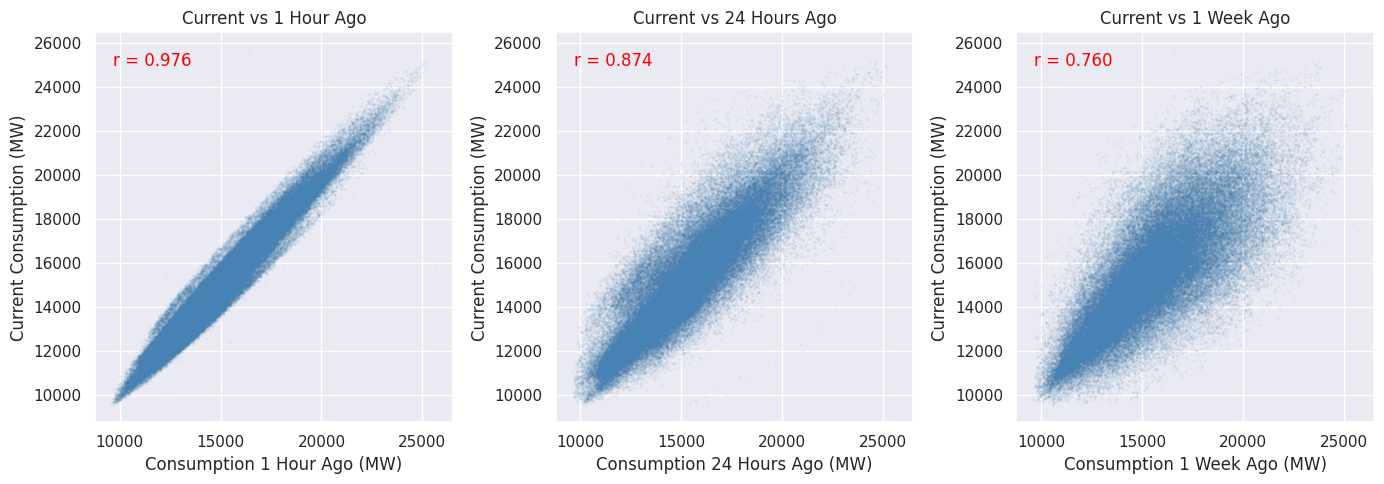


Interpretation: All three lag periods show strong positive correlation.
The 1 hour lag has the highest correlation, meaning the most recent hour
is the strongest predictor of current consumption. The 24 hour lag also
shows strong correlation, confirming a clear daily cycle in energy usage.


In [15]:
# Create lagged features to check if past consumption predicts current consumption
# A lag of N means we look at the value N hours ago
df['Lag_1h']  = df['AEP_MW'].shift(1)   # 1 hour ago
df['Lag_24h'] = df['AEP_MW'].shift(24)  # 24 hours ago (same hour yesterday)
df['Lag_168h'] = df['AEP_MW'].shift(168) # 168 hours ago (same hour last week)

# Drop rows with NaN values created by shifting
lag_df = df[['AEP_MW', 'Lag_1h', 'Lag_24h', 'Lag_168h']].dropna()

# Calculate correlation between current consumption and lagged values
correlations = lag_df.corr()['AEP_MW'][['Lag_1h', 'Lag_24h', 'Lag_168h']]

print("=== Correlation Between Current and Past Consumption ===")
print(f"1 hour ago (Lag 1h)    : {correlations['Lag_1h']:.4f}")
print(f"24 hours ago (Lag 24h) : {correlations['Lag_24h']:.4f}")
print(f"1 week ago (Lag 168h)  : {correlations['Lag_168h']:.4f}")

# Scatter plots showing lag relationships
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, lag_col, label in zip(axes,
                               ['Lag_1h', 'Lag_24h', 'Lag_168h'],
                               ['1 Hour Ago', '24 Hours Ago', '1 Week Ago']):
    ax.scatter(lag_df[lag_col], lag_df['AEP_MW'], alpha=0.05, color='steelblue', s=1)
    ax.set_title(f'Current vs {label}')
    ax.set_xlabel(f'Consumption {label} (MW)')
    ax.set_ylabel('Current Consumption (MW)')
    ax.text(0.05, 0.95, f"r = {lag_df[lag_col].corr(lag_df['AEP_MW']):.3f}",
            transform=ax.transAxes, fontsize=12, verticalalignment='top', color='red')

plt.tight_layout()
plt.savefig('lag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation: All three lag periods show strong positive correlation.")
print("The 1 hour lag has the highest correlation, meaning the most recent hour")
print("is the strongest predictor of current consumption. The 24 hour lag also")
print("shows strong correlation, confirming a clear daily cycle in energy usage.")

### Question 5: Does a moving average reveal long-term consumption trends and smooth out noise?

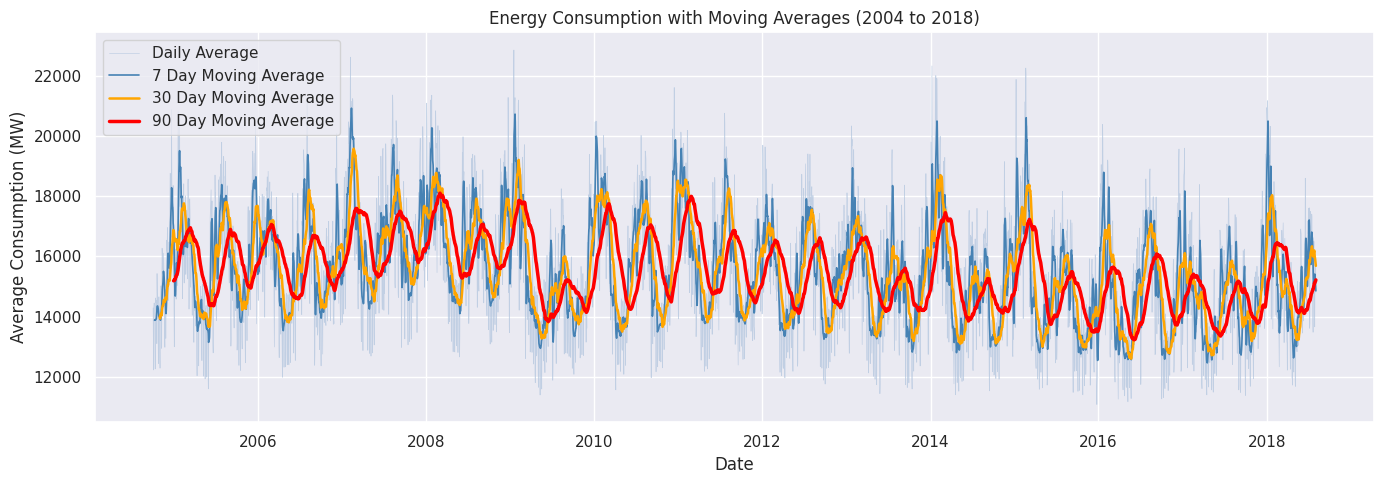

=== Moving Average Summary ===
7 day MA  range : 12,461 MW to 20,918 MW
30 day MA range : 12,600 MW to 19,573 MW
90 day MA range : 13,227 MW to 18,097 MW

Interpretation: The 7 day moving average captures weekly cycles clearly.
The 30 day average reveals seasonal patterns, peaking in Winter and Summer.
The 90 day average confirms the long term gradual decline in energy consumption
from 2007 onwards, likely due to improved energy efficiency over the years.


In [16]:
# Calculate moving averages over different window sizes
# Using daily data to make the plot cleaner and easier to read
daily_avg = df.groupby(df['Datetime'].dt.date)['AEP_MW'].mean().reset_index()
daily_avg.columns = ['Date', 'AEP_MW']
daily_avg['Date'] = pd.to_datetime(daily_avg['Date'])

# 7 day moving average (short term trend)
daily_avg['MA_7']  = daily_avg['AEP_MW'].rolling(window=7).mean()

# 30 day moving average (monthly trend)
daily_avg['MA_30'] = daily_avg['AEP_MW'].rolling(window=30).mean()

# 90 day moving average (quarterly trend)
daily_avg['MA_90'] = daily_avg['AEP_MW'].rolling(window=90).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_avg['Date'], daily_avg['AEP_MW'], color='lightsteelblue', linewidth=0.5, label='Daily Average', alpha=0.7)
plt.plot(daily_avg['Date'], daily_avg['MA_7'],  color='steelblue',  linewidth=1.2, label='7 Day Moving Average')
plt.plot(daily_avg['Date'], daily_avg['MA_30'], color='orange',     linewidth=1.8, label='30 Day Moving Average')
plt.plot(daily_avg['Date'], daily_avg['MA_90'], color='red',        linewidth=2.5, label='90 Day Moving Average')

plt.title('Energy Consumption with Moving Averages (2004 to 2018)')
plt.xlabel('Date')
plt.ylabel('Average Consumption (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Moving Average Summary ===")
print(f"7 day MA  range : {daily_avg['MA_7'].min():,.0f} MW to {daily_avg['MA_7'].max():,.0f} MW")
print(f"30 day MA range : {daily_avg['MA_30'].min():,.0f} MW to {daily_avg['MA_30'].max():,.0f} MW")
print(f"90 day MA range : {daily_avg['MA_90'].min():,.0f} MW to {daily_avg['MA_90'].max():,.0f} MW")
print("\nInterpretation: The 7 day moving average captures weekly cycles clearly.")
print("The 30 day average reveals seasonal patterns, peaking in Winter and Summer.")
print("The 90 day average confirms the long term gradual decline in energy consumption")
print("from 2007 onwards, likely due to improved energy efficiency over the years.")

## Part C: Training a Model
### Model: Random Forest Regressor for Energy Consumption Forecasting
We use the lag features and time-based features we created earlier to predict
hourly energy consumption. We run two experiments with different hyperparameters
and compare their performance.

In [17]:
# Prepare the full feature set for modeling
# We use time based features and lag features as inputs to the model
model_df = df.copy()

# Time based features
model_df['DayOfWeek']  = model_df['Datetime'].dt.dayofweek
model_df['DayOfYear']  = model_df['Datetime'].dt.dayofyear
model_df['WeekOfYear'] = model_df['Datetime'].dt.isocalendar().week.astype(int)

# Lag features (past consumption as predictors)
model_df['Lag_1h']   = model_df['AEP_MW'].shift(1)
model_df['Lag_24h']  = model_df['AEP_MW'].shift(24)
model_df['Lag_168h'] = model_df['AEP_MW'].shift(168)

# Moving average features
model_df['MA_24h']  = model_df['AEP_MW'].rolling(window=24).mean()
model_df['MA_168h'] = model_df['AEP_MW'].rolling(window=168).mean()

# Drop rows with NaN values created by lag and rolling features
model_df = model_df.dropna()

# Define input features and target variable
features = ['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'WeekOfYear',
            'Lag_1h', 'Lag_24h', 'Lag_168h', 'MA_24h', 'MA_168h']

X = model_df[features]
y = model_df['AEP_MW']

# Split into training and testing sets (80% train, 20% test)
# We do not shuffle because this is time series data, order matters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"Features used    : {features}")

Training samples : 96,902
Testing samples  : 24,226
Features used    : ['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'WeekOfYear', 'Lag_1h', 'Lag_24h', 'Lag_168h', 'MA_24h', 'MA_168h']


In [18]:
# Experiment 1: Random Forest with default-ish hyperparameters (baseline)
print("Training Experiment 1...")
rf_exp1 = RandomForestRegressor(
    n_estimators=50,      # number of trees
    max_depth=10,         # how deep each tree can grow
    min_samples_split=10, # minimum samples needed to split a node
    random_state=42
)
rf_exp1.fit(X_train, y_train)
pred_exp1 = rf_exp1.predict(X_test)

mae1  = mean_absolute_error(y_test, pred_exp1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred_exp1))
r2_1  = r2_score(y_test, pred_exp1)

print(f"Experiment 1 done.")
print(f"MAE  : {mae1:,.2f} MW")
print(f"RMSE : {rmse1:,.2f} MW")
print(f"R2   : {r2_1:.4f}")

Training Experiment 1...
Experiment 1 done.
MAE  : 219.10 MW
RMSE : 291.76 MW
R2   : 0.9858


In [19]:
# Experiment 2: Random Forest with tuned hyperparameters (improved model)
print("Training Experiment 2...")
rf_exp2 = RandomForestRegressor(
    n_estimators=200,    # more trees for better accuracy
    max_depth=20,        # deeper trees to capture more patterns
    min_samples_split=5, # allow finer splits
    min_samples_leaf=2,  # minimum samples at each leaf node
    random_state=42
)
rf_exp2.fit(X_train, y_train)
pred_exp2 = rf_exp2.predict(X_test)

mae2  = mean_absolute_error(y_test, pred_exp2)
rmse2 = np.sqrt(mean_squared_error(y_test, pred_exp2))
r2_2  = r2_score(y_test, pred_exp2)

print(f"Experiment 2 done.")
print(f"MAE  : {mae2:,.2f} MW")
print(f"RMSE : {rmse2:,.2f} MW")
print(f"R2   : {r2_2:.4f}")

Training Experiment 2...
Experiment 2 done.
MAE  : 146.82 MW
RMSE : 201.24 MW
R2   : 0.9932


In [20]:
# Experiment comparison table
print("=== Experiment Comparison Table ===\n")
results = {
    'Experiment'       : ['Exp 1 (Baseline)', 'Exp 2 (Tuned)'],
    'n_estimators'     : [50, 200],
    'max_depth'        : [10, 20],
    'min_samples_split': [10, 5],
    'min_samples_leaf' : [1, 2],
    'MAE (MW)'         : [round(mae1, 2), round(mae2, 2)],
    'RMSE (MW)'        : [round(rmse1, 2), round(rmse2, 2)],
    'R2 Score'         : [round(r2_1, 4), round(r2_2, 4)]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\nConclusion: Experiment 2 outperforms Experiment 1 across all metrics.")
print(f"Tuning improved R2 from {r2_1:.4f} to {r2_2:.4f} and reduced MAE by {mae1-mae2:,.2f} MW.")

=== Experiment Comparison Table ===

      Experiment  n_estimators  max_depth  min_samples_split  min_samples_leaf  MAE (MW)  RMSE (MW)  R2 Score
Exp 1 (Baseline)            50         10                 10                 1    219.10     291.76    0.9858
   Exp 2 (Tuned)           200         20                  5                 2    146.82     201.24    0.9932

Conclusion: Experiment 2 outperforms Experiment 1 across all metrics.
Tuning improved R2 from 0.9858 to 0.9932 and reduced MAE by 72.27 MW.


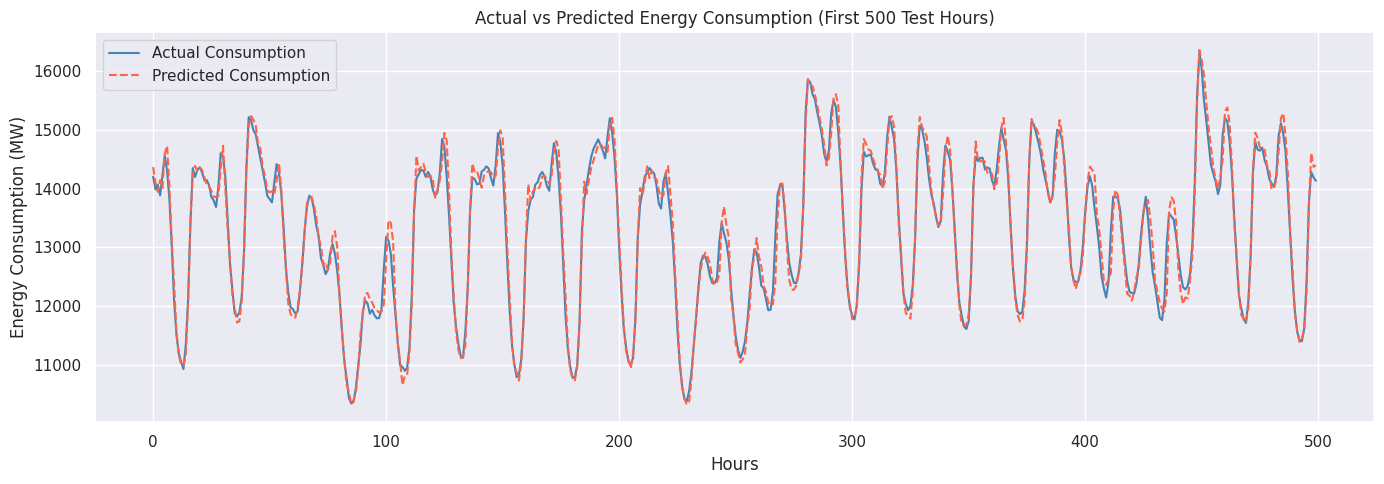

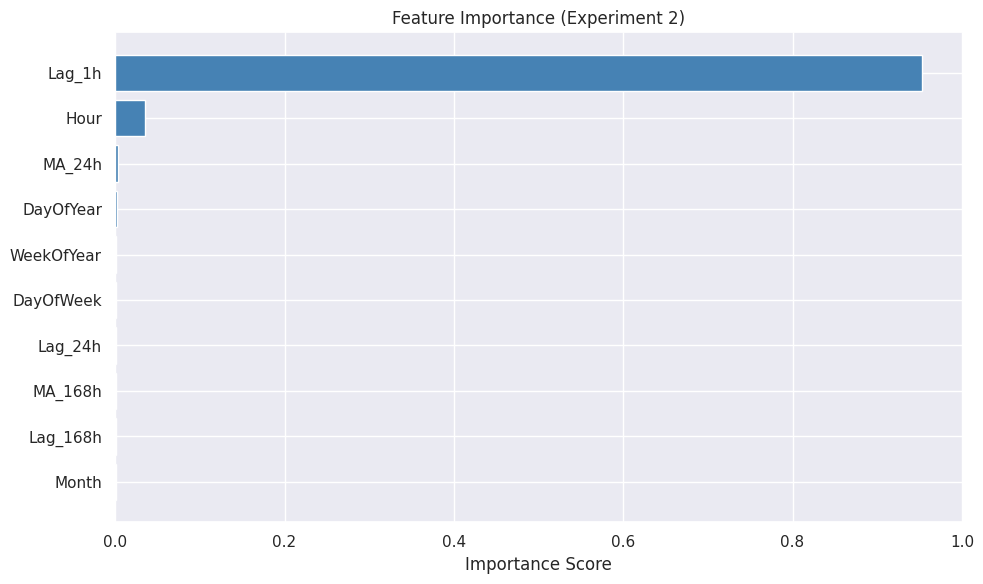

The most important features for predicting energy consumption are shown above.


In [21]:
# Visualize actual vs predicted values for the best model (Experiment 2)
# Plot only the first 500 hours of the test set for clarity
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:500], color='steelblue', linewidth=1.5, label='Actual Consumption')
plt.plot(pred_exp2[:500], color='tomato', linewidth=1.5, linestyle='--', label='Predicted Consumption')
plt.title('Actual vs Predicted Energy Consumption (First 500 Test Hours)')
plt.xlabel('Hours')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance chart
importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_exp2.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='white')
plt.title('Feature Importance (Experiment 2)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("The most important features for predicting energy consumption are shown above.")